# Geometric Shack–Hartmann wavefront sensing

**Scientific question.** When a Shack–Hartmann wavefront sensor observes a pure
Zernike tip, does the mean measured sub-aperture slope track the applied
wavefront gradient with the correct sign and near-unit gain — and does a pure
x-tilt leave the y-axis untouched?

This tutorial builds the installed detector-level sensor and drives it with
mode fixtures synthesized by the package. It defines no sensing engine of its
own.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.modes import (
    normalize_mode_to_unit_pupil_rms,
    polar_pupil_coordinates,
    zernike_named_modes,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9

## Configuration

In [2]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(64, 64),
    n_lenslets_across=8,
    min_fill_fraction=0.5,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=2e4),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
pupil = geometry.pupil_geometry
rho, theta = polar_pupil_coordinates(pupil.x_m, pupil.y_m, TELESCOPE_DIAMETER_M)
modes = zernike_named_modes(rho, theta, geometry.pupil_mask)
print(f"{geometry.n_subapertures} illuminated sub-apertures")

52 illuminated sub-apertures


## Simulation call

In [3]:
def slope_response(mode_name, amplitude_rad):
    unit_mode = normalize_mode_to_unit_pupil_rms(modes[mode_name], geometry.pupil_mask)
    # Scale so the pupil-edge gradient equals the requested angular slope.
    gradient = np.gradient(
        np.where(geometry.pupil_mask, unit_mode, 0.0),
        pupil.pixel_spacing_xy_m[0],
        axis=1,
    )
    opd_m = unit_mode * (amplitude_rad / np.nanmax(np.abs(gradient)))
    measurement = sensor.measure(
        np.where(geometry.pupil_mask, opd_m, 0.0),
        random_streams=NamedRandomStreams(SEED),
        include_noise=False,
    )
    values = np.asarray(measurement.vector.values, dtype=float)
    return values[0::2], values[1::2]

applied_rad = 2.0e-6
tipx_x, tipx_y = slope_response("tip_x", applied_rad)
tipy_x, tipy_y = slope_response("tip_y", applied_rad)

## Diagnostic table

In [4]:
table = pd.DataFrame(
    [
        ("tip_x", "x-slope mean", float(np.mean(tipx_x))),
        ("tip_x", "y-slope mean", float(np.mean(tipx_y))),
        ("tip_y", "x-slope mean", float(np.mean(tipy_x))),
        ("tip_y", "y-slope mean", float(np.mean(tipy_y))),
    ],
    columns=["applied mode", "measured", "mean slope (px)"],
)
table

,applied mode,measured,mean slope (px)
0,tip_x,x-slope mean,9.244969e-02
1,tip_x,y-slope mean,4.235928e-15
2,tip_y,x-slope mean,2.596214e-15
3,tip_y,y-slope mean,1.847510e-01


## Plot

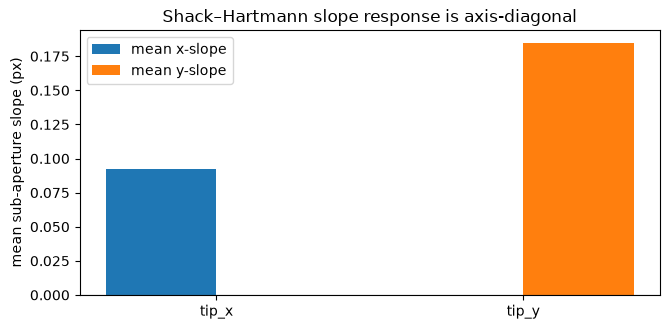

In [5]:
figure, axis = plt.subplots(figsize=(6.8, 3.4))
labels = ["tip_x", "tip_y"]
x_means = [np.mean(tipx_x), np.mean(tipy_x)]
y_means = [np.mean(tipx_y), np.mean(tipy_y)]
positions = np.arange(len(labels))
axis.bar(positions - 0.18, x_means, width=0.36, label="mean x-slope")
axis.bar(positions + 0.18, y_means, width=0.36, label="mean y-slope")
axis.axhline(0.0, color="0.4", linewidth=0.8)
axis.set_xticks(positions)
axis.set_xticklabels(labels)
axis.set_ylabel("mean sub-aperture slope (px)")
axis.set_title("Shack–Hartmann slope response is axis-diagonal")
axis.legend()
figure.tight_layout()
plt.show()

## Interpretation

Each applied tilt produces a strong mean slope on its own axis and a
near-zero mean slope on the orthogonal axis, so the sensor's response is
diagonal in the tip/tilt basis with a consistent sign. This is the geometric
foundation the reconstruction and closed-loop tutorials build on: the
interaction matrix is just this response measured for every actuator instead
of for two global tilts.

## Limitations

- Only tip modes are exercised here; higher orders couple partially between
  neighbouring sub-apertures.
- Noise is disabled to isolate the geometric response; photon and read noise
  are studied in `02_detector_centroiding.ipynb`.
- Absolute gain depends on the spot-sampling and centroid window, which are
  fixed to the library defaults for this pupil.